# try the not renamed event log instead 

- import libraries:

In [22]:
import pm4py # process mining library
import pandas as pd # data manipulation library
import os # operating system library for file handling
import matplotlib.pyplot as plt # plotting library for visualizations
import numpy as np # numerical computing library for data analysis
import networkx as nx # library for graph analysis and visualization
import math # mathematical functions for calculations

- load only completed and relabled events 

In [2]:
df = pd.read_csv("../data/complete_log.csv", low_memory=False)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed', utc=True)
event_log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')


### Define own Simplicity metrics

In the book [3], the following metrics are mentioned as candidates for simplicity metrics by analyzing the complexity of the underlying graph:
- Size
- Diameter
- Density
- Connectivity
- Node Degree

Given that the graph functions as a process model, additional domain-specific metrics can be applied:

- Sequentiality: Gateway arcs divided by total arcs.
- Structuredness: Proportion of reducible, well-structured parts in the model.
- Depth: Average or max depth of split/join constructs.
- Gateway Mismatch: Difference between input and output arcs for connected gateways.
- Gateway Heterogeneity: Entropy of gateway types used.
- Control Flow Complexity: Sum of choices based on split types and outgoing arcs.
- Cyclicity: Ratio of nodes in cycles to total nodes.
- Token Splits: Number of concurrent threads from AND/OR-splits.


[3] Josep Carmona, Boudewijn F. van Dongen, Andreas Solti, and Matthias Weidlich. *Conformance Checking - Relating Processes and Models*. Springer, 2018, pp. 223–224.

- a first simple simplicity metrics is the size (arcs and nodes) that is implemented in the following way:

In [3]:
def calculate_node_size(net):
    """
    Calculates the total number of nodes in a pm4py Petri net.
    Nodes = Places + Transitions
    """
    num_places = len(net.places)
    num_transitions = len(net.transitions)
    
    return num_places + num_transitions

def calculate_arc_size(net):
    """
    Calculates the total number of arcs (edges) in a pm4py Petri net.
    """
    return len(net.arcs)

- another metric that makes sense in general is the cyclicity of the net
- implementation:

In [4]:
def calculate_cyclicity(net):
    """
    Calculates the cyclicity of a pm4py Petri net.
    Cyclicity = (number of nodes within cycles) / (total number of nodes)
    
    :param net: pm4py Petri net object
    :return: Float representing the cyclicity metric (between 0.0 and 1.0)
    """
    # 1. Calculate total number of nodes (Places + Transitions)
    total_nodes = len(net.places) + len(net.transitions)
    
    if total_nodes == 0:
        return 0.0
        
    # 2. Build a NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add all places and transitions as nodes
    for place in net.places:
        G.add_node(place)
    for transition in net.transitions:
        G.add_node(transition)
        
    # Add all arcs as directed edges
    for arc in net.arcs:
        G.add_edge(arc.source, arc.target)
        
    # 3. Identify nodes in cycles
    # A node is in a cycle if it is part of a Strongly Connected Component (SCC)
    # with more than 1 node, or if it is a single node with a self-loop.
    nodes_in_cycles = set()
    
    for scc in nx.strongly_connected_components(G):
        if len(scc) > 1:
            # All nodes in an SCC of size > 1 are part of a cycle
            nodes_in_cycles.update(scc)
        elif len(scc) == 1:
            # Check for self-loops for single-node components
            node = list(scc)[0]
            if G.has_edge(node, node):
                nodes_in_cycles.add(node)
                
    # 4. Calculate the cyclicity ratio
    cyclicity = len(nodes_in_cycles) / total_nodes
    
    return cyclicity

### process discovery 

- inductive Miner

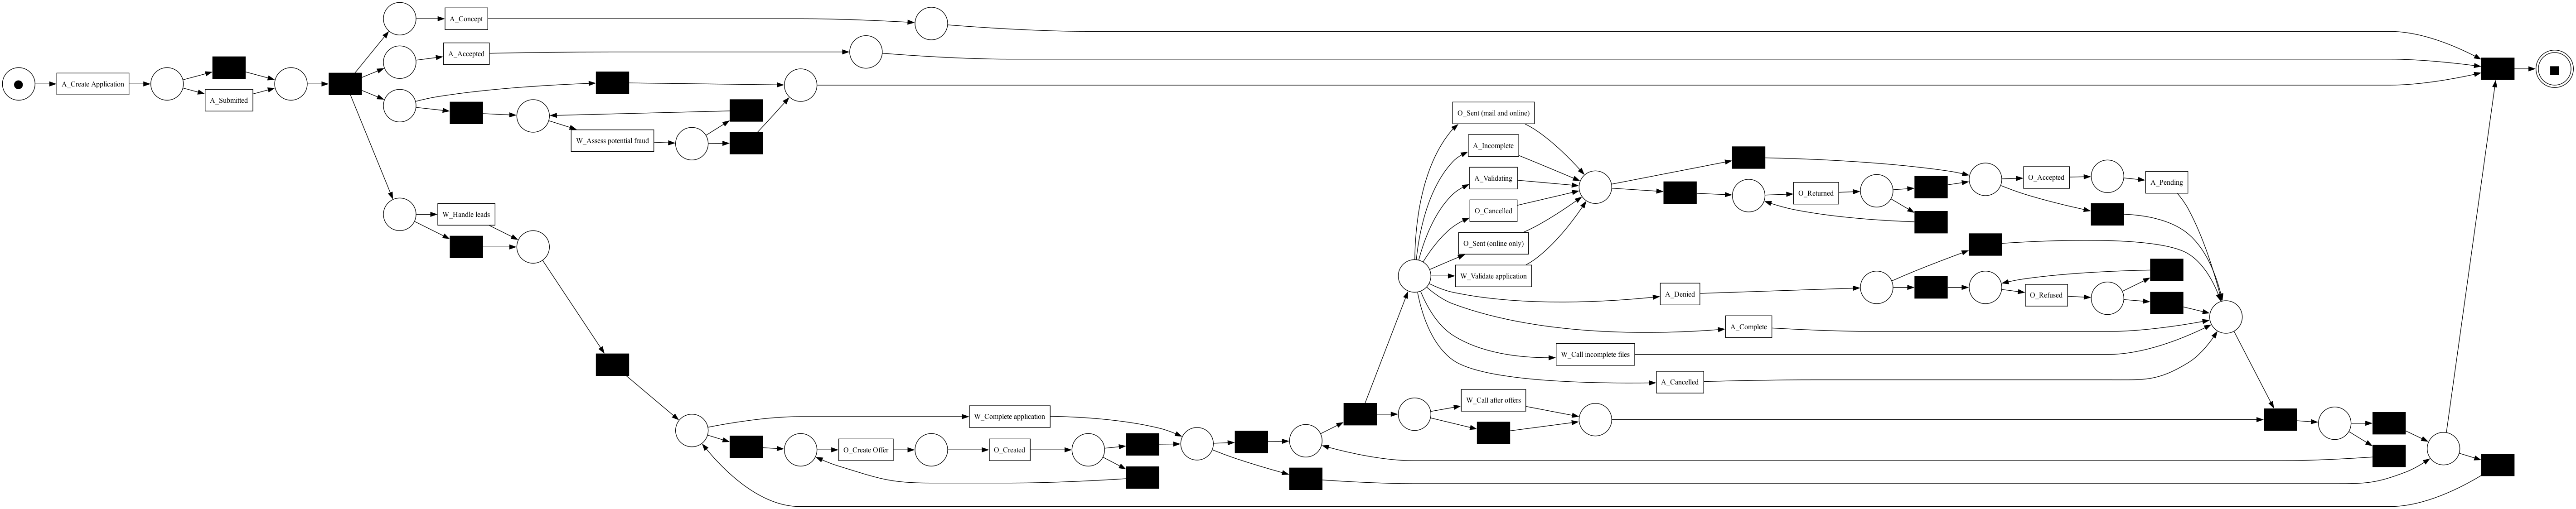

In [5]:
inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking = pm4py.discover_petri_net_inductive(event_log)
pm4py.view_petri_net(inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking)


- calculate conformance metrics

In [6]:
inductive_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking)
inductive_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking)
inductive_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking)
print(f"Generalization: {inductive_generalization_all:.4f}")
print(f"Precision: {inductive_precision_all:.4f}")
print(f"Fitness: {inductive_fitness_all}")

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization: 0.9757
Precision: 0.2926
Fitness: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}


- calculate simplicity

In [7]:
inductive_node_size_all = calculate_node_size(inductive_net_all)
inductive_arc_size_all = calculate_arc_size(inductive_net_all)
inductive_cyclicity_all = calculate_cyclicity(inductive_net_all)
print(f"Node Size: {inductive_node_size_all}")
print(f"Arc Size: {inductive_arc_size_all}")
print(f"Cyclicity: {inductive_cyclicity_all:.4f}")

Node Size: 87
Arc Size: 114
Cyclicity: 0.7126


- store the petri net in the correct directory

In [8]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic_complete"
file_name = "petri_net_inductive.pdf"
full_path = os.path.join(target_dir, file_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking, full_path)

''

In [9]:
target_dir = "../petrinets/basic_complete"
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

file_path = os.path.join(target_dir, "inductive_model.pnml")

# Save the Petri net model
pm4py.write_pnml(inductive_net_all, inductive_all_initial_marking, inductive_all_final_marking, file_path)

- Alpha Miner

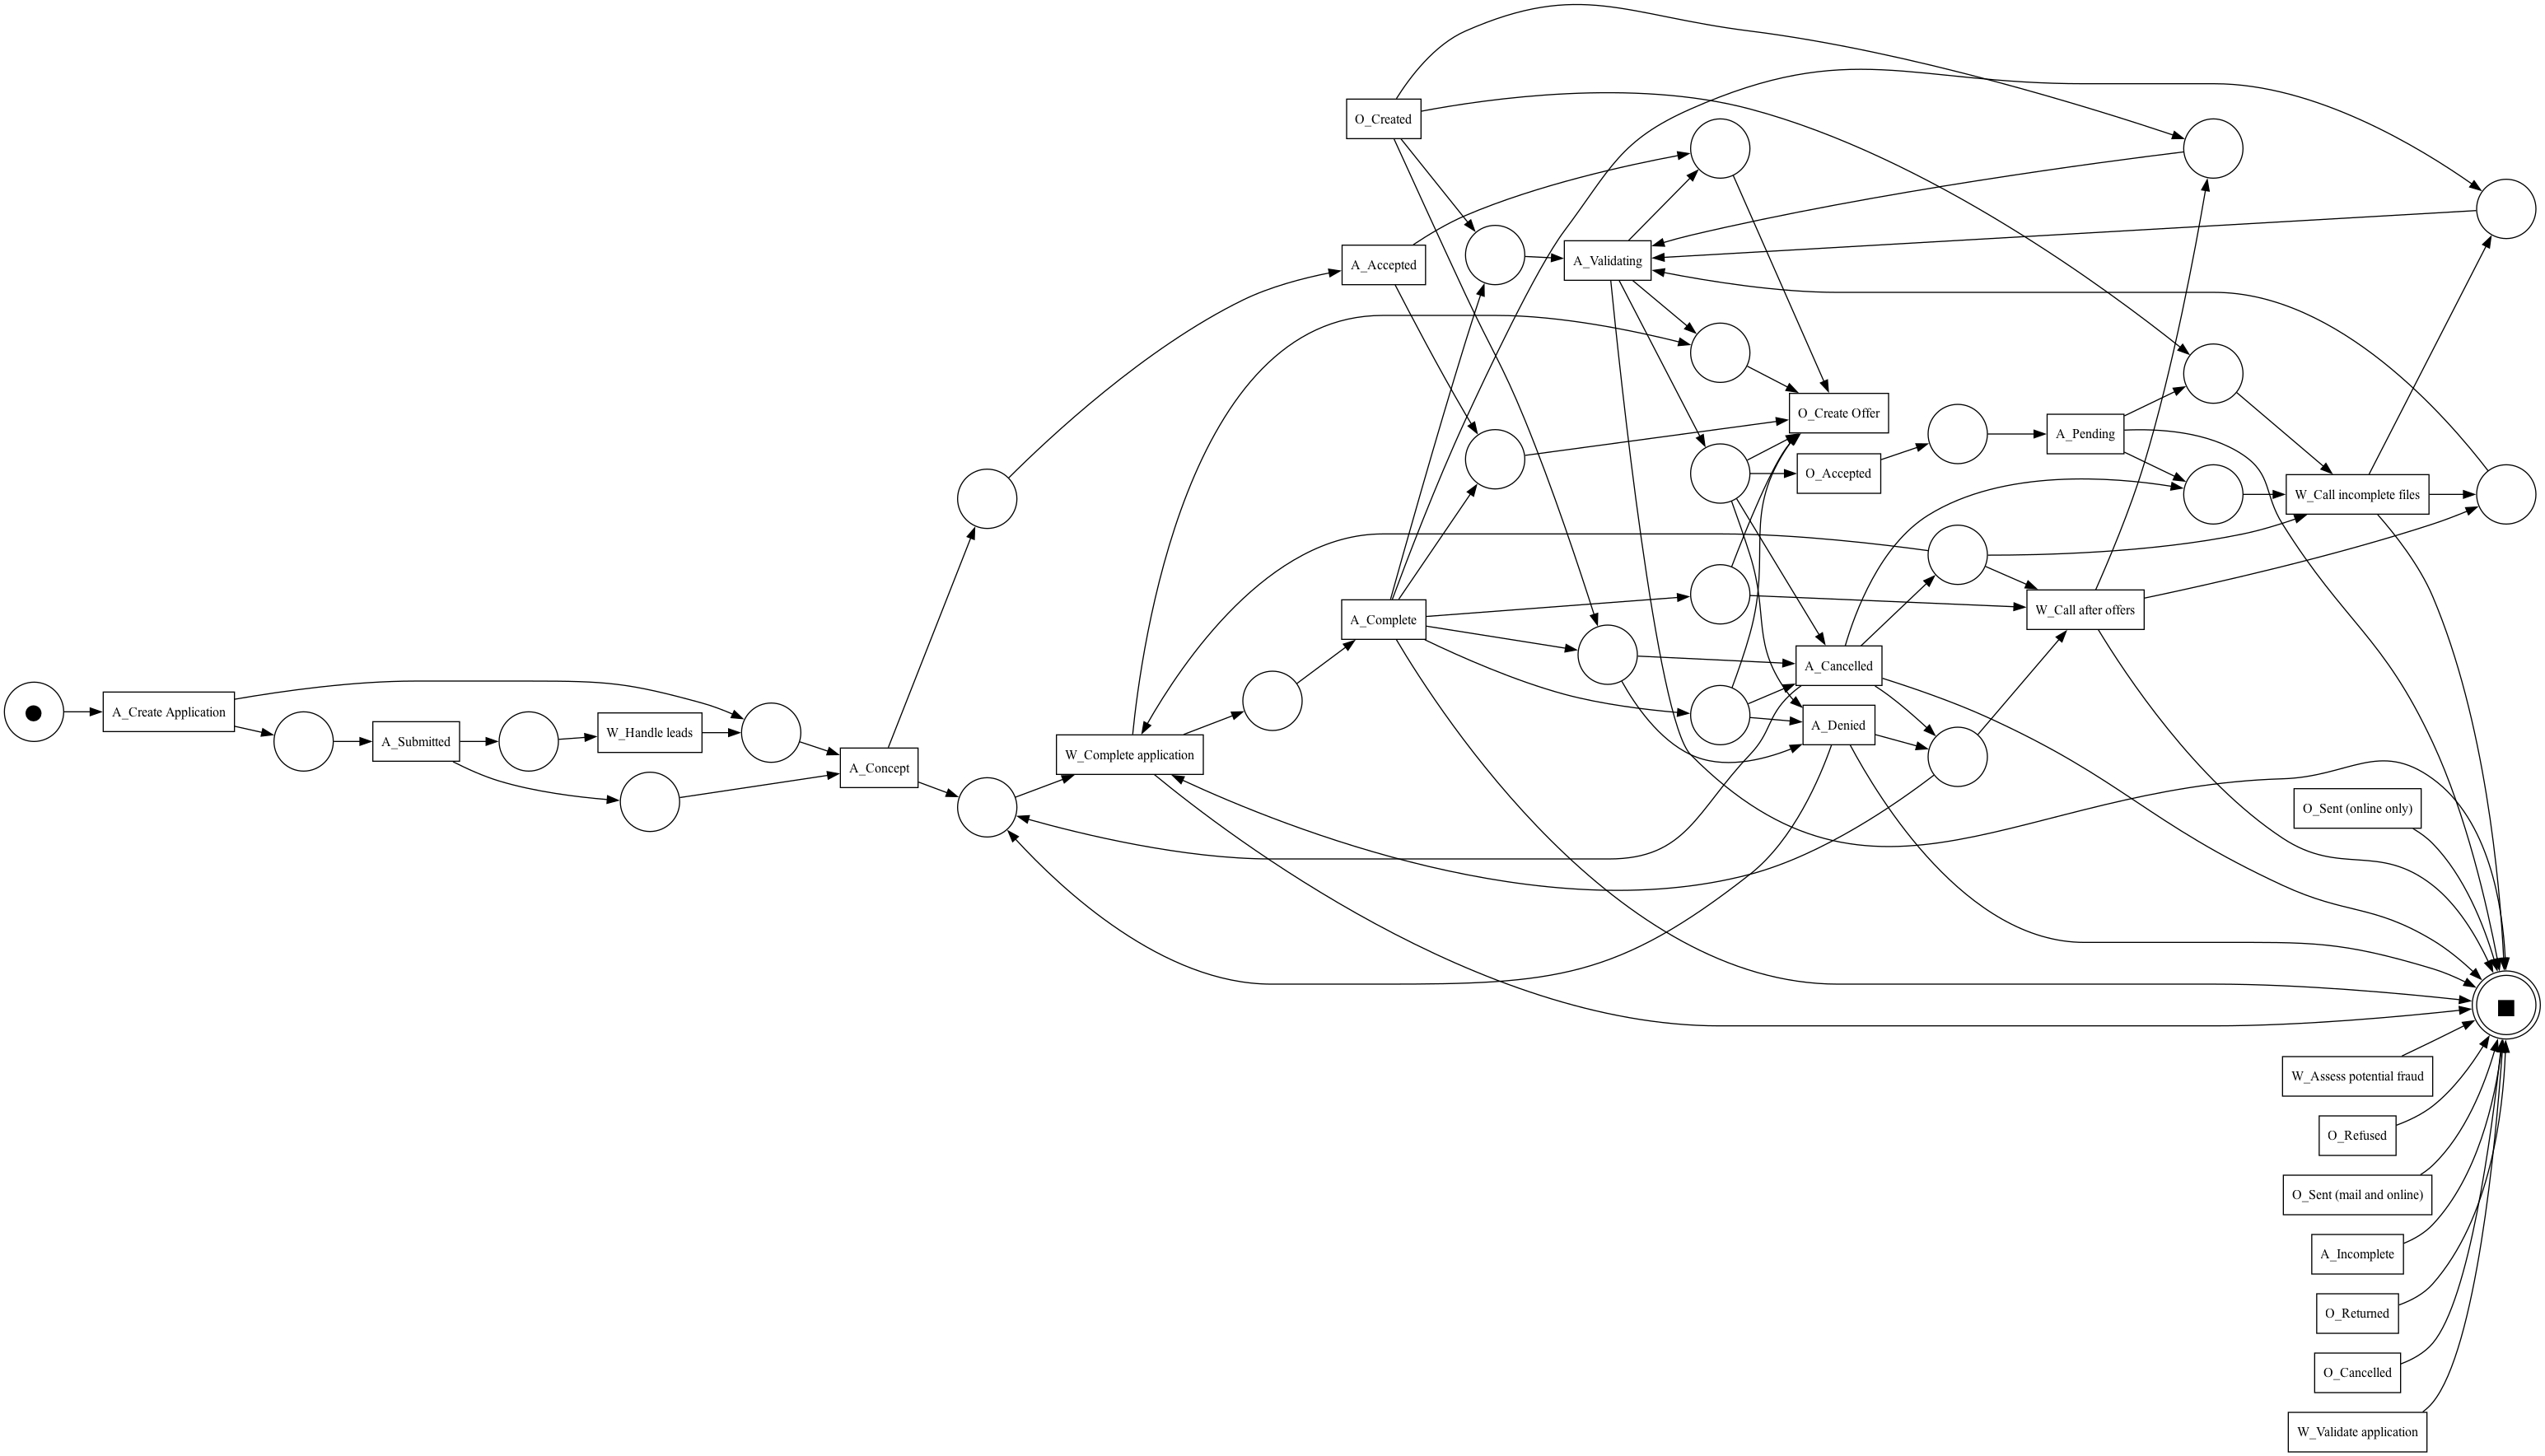

In [10]:
alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking = pm4py.discover_petri_net_alpha(event_log)
pm4py.view_petri_net(alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking)

- calculate conformance metrics:

In [11]:
alpha_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking)
alpha_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking)
alpha_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking)
print(f"Generalization: {alpha_generalization_all:.4f}")
print(f"Precision: {alpha_precision_all:.4f}")
print(f"Fitness: {alpha_fitness_all}")

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization: 0.9870
Precision: 0.1259
Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.50011172988835, 'log_fitness': 0.495774473479623, 'percentage_of_fitting_traces': 0.0}


- calculate simplicity

In [12]:
alpha_node_size_all = calculate_node_size(alpha_all_net)
alpha_arc_size_all = calculate_arc_size(alpha_all_net)
alpha_cyclicity_all = calculate_cyclicity(alpha_all_net)
print(f"Node Size: {alpha_node_size_all}")
print(f"Arc Size: {alpha_arc_size_all}")
print(f"Cyclicity: {alpha_cyclicity_all:.4f}")

Node Size: 49
Arc Size: 87
Cyclicity: 0.4898


- store the petri net in the correct directory

In [13]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic_complete"
file_name = "petri_net_alpha.pdf"
full_path = os.path.join(target_dir, file_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    
# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking, full_path)

''

In [14]:
target_dir = "../petrinets/basic_complete"
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

file_path = os.path.join(target_dir, "alpha_model.pnml")

# Save the Petri net model
pm4py.write_pnml(alpha_all_net, alpha_all_initial_marking, alpha_all_final_marking, file_path)

- heuristics miner

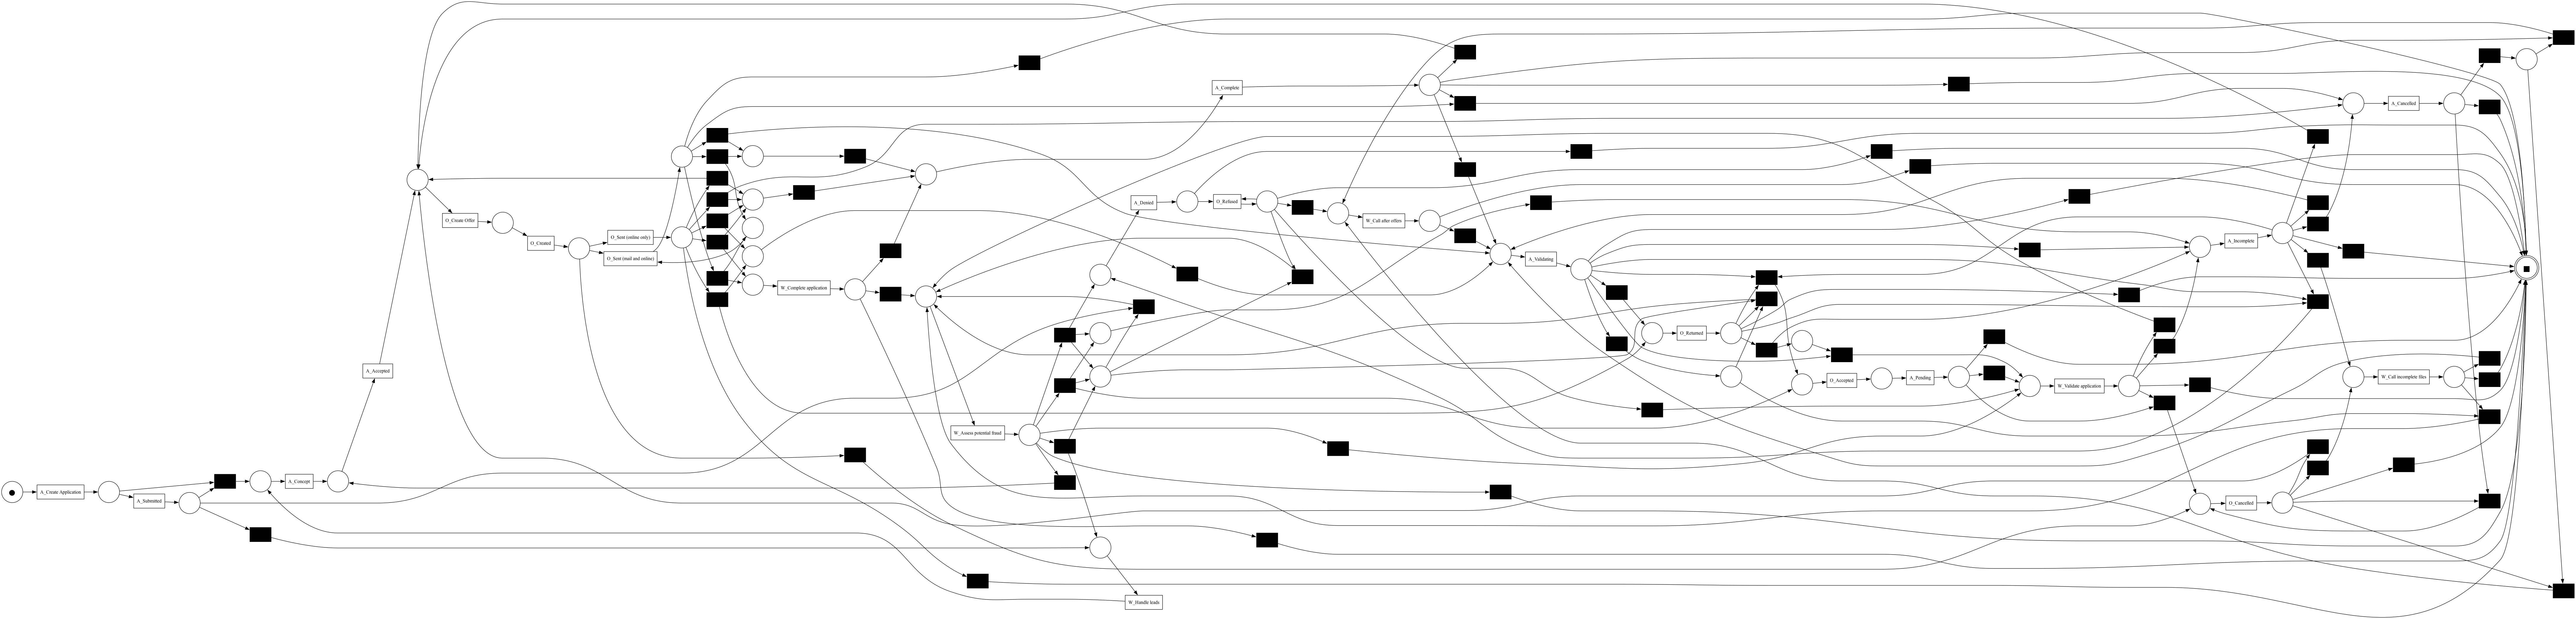

In [15]:
heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking = pm4py.discover_petri_net_heuristics(event_log)
pm4py.view_petri_net(heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking)

- calculate conformance metrics:

In [16]:
heuristics_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking)
heuristics_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking)
heuristics_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking)
print(f"Generalization: {heuristics_generalization_all:.4f}")
print(f"Precision: {heuristics_precision_all:.4f}")
print(f"Fitness: {heuristics_fitness_all}")

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization: 0.8477
Precision: 0.9979
Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.824743115573001, 'log_fitness': 0.8340704756490401, 'percentage_of_fitting_traces': 0.0}


- calculate simplicity

In [17]:
heuristic_node_size_all = calculate_node_size(heuristics_all_net)
heuristic_arc_size_all = calculate_arc_size(heuristics_all_net)
heuristic_cyclicity_all = calculate_cyclicity(heuristics_all_net)
print(f"Node Size: {heuristic_node_size_all}")
print(f"Arc Size: {heuristic_arc_size_all}")
print(f"Cyclicity: {heuristic_cyclicity_all:.4f}")

Node Size: 143
Arc Size: 220
Cyclicity: 0.8322


- store the petri net in the correct directory

In [18]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic_complete"
file_name = "petri_net_heuristics.pdf"
full_path = os.path.join(target_dir, file_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking, full_path)

''

In [19]:
target_dir = "../petrinets/basic_complete"
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

file_path = os.path.join(target_dir, "heuristics_model.pnml")

# Save the Petri net model
pm4py.write_pnml(heuristics_all_net, heuristics_all_initial_marking, heuristics_all_final_marking, file_path)

- ILP miner:

- -> takes way to much time and Compute resources

### Comparison over relevant metrics

In [20]:
# Initialize the dictionary with lists for both conformance and simplicity metrics
metrics_dict = {
    'Model': [],
    'Fitness (Log)': [],
    'Fitness (Avg Trace)': [],
    'Fitness (% Fit Traces)': [],
    'Precision': [],
    'Generalization': [],
    'Node Size': [],
    'Arc Size': [],
    'Cyclicity': []
}

# Add base models
metrics_dict['Model'].extend([
    'Inductive Miner (All Cases)', 
    'Alpha Miner (All Cases)', 
    'Heuristics Miner (All Cases)'
])

# Add Conformance Metrics 
# (Make sure these variables have been generated in previous cells)
metrics_dict['Fitness (Log)'].extend([
    inductive_fitness_all['log_fitness'], 
    alpha_fitness_all['log_fitness'], 
    heuristics_fitness_all['log_fitness']
])

metrics_dict['Fitness (Avg Trace)'].extend([
    inductive_fitness_all['average_trace_fitness'], 
    alpha_fitness_all['average_trace_fitness'], 
    heuristics_fitness_all['average_trace_fitness']
])

metrics_dict['Fitness (% Fit Traces)'].extend([
    inductive_fitness_all['perc_fit_traces'], 
    alpha_fitness_all['perc_fit_traces'], 
    heuristics_fitness_all['perc_fit_traces']
])

metrics_dict['Precision'].extend([
    inductive_precision_all, 
    alpha_precision_all, 
    heuristics_precision_all
])

metrics_dict['Generalization'].extend([
    inductive_generalization_all, 
    alpha_generalization_all, 
    heuristics_generalization_all
])

# Add Simplicity Metrics
metrics_dict['Node Size'].extend([
    inductive_node_size_all, 
    alpha_node_size_all, 
    heuristic_node_size_all
])

metrics_dict['Arc Size'].extend([
    inductive_arc_size_all, 
    alpha_arc_size_all, 
    heuristic_arc_size_all
])

metrics_dict['Cyclicity'].extend([
    inductive_cyclicity_all, 
    alpha_cyclicity_all, 
    heuristic_cyclicity_all
])

# Create DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Print the formatted table
print("=" * 135)
print("CONFORMANCE & SIMPLICITY METRICS - DISCOVERED MODELS (All Cases)")
print("=" * 135)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 135)

CONFORMANCE & SIMPLICITY METRICS - DISCOVERED MODELS (All Cases)
                       Model  Fitness (Log)  Fitness (Avg Trace)  Fitness (% Fit Traces)  Precision  Generalization  Node Size  Arc Size  Cyclicity
 Inductive Miner (All Cases)         1.0000               1.0000                100.0000     0.2926          0.9757         87       114     0.7126
     Alpha Miner (All Cases)         0.4958               0.5001                  0.0000     0.1259          0.9870         49        87     0.4898
Heuristics Miner (All Cases)         0.8341               0.8247                  0.0000     0.9979          0.8477        143       220     0.8322


-> The Heuristics Miner achieves high fitness, precision, and generalization across all cases, but this comes at the cost of simplicity, resulting in a highly complex model.

#### Hypothesis:
- Process model complexity is primarily a function of high variant diversity. 
- restricting the Heuristics Miner to less variants, can generate a simpler Petri net. 
- Although the event log contains 5,623 unique variants, 610 variants represent 80% of the cases 
- focusing on the highest-impact subset should significantly reduce structural clutter while still capturing the core process behavior.

### Approach:
- identify the minimal variant subset required to balance model fitness with simplicity.

In [23]:
output_dir = "../petrinets/complete_heuristic_variants"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Calculate variant distribution and coverage for the entire log
variants_dict = pm4py.get_variants(event_log)
# Handle both count-based and trace-list-based variant dictionaries
first_val = next(iter(variants_dict.values()))
if isinstance(first_val, int):
    variant_counts = pd.Series(variants_dict).sort_values(ascending=False)
else:
    variant_counts = pd.Series({k: len(v) for k, v in variants_dict.items()}).sort_values(ascending=False)

variant_coverage_series = variant_counts.cumsum() / variant_counts.sum()
total_unique_variants = len(variant_counts)

# 2. Define the target percentages of unique variants
percentages = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 95, 100]
results_list = []

print(f"Analyzing {total_unique_variants} unique variants...")

for p in percentages:
    # Calculate how many variants (K) to include
    k = max(1, math.ceil((p / 100) * total_unique_variants))
    
    # Get the top K variant keys and their case coverage
    top_k_variant_keys = variant_counts.iloc[:k].index.tolist()
    case_coverage = variant_coverage_series.iloc[k-1]
    
    # Filter log for training
    filtered_log = pm4py.filter_variants(event_log, top_k_variant_keys)
    
    # 3. Discover Petri net
    net, im, fm = pm4py.discover_petri_net_heuristics(filtered_log)
    
    # 4. Save artifacts (.pnml and .pdf)
    pnml_path = os.path.join(output_dir, f"petri_model_{p}.pnml")
    pdf_path = os.path.join(output_dir, f"petri_model_{p}.pdf")
    pm4py.write_pnml(net, im, fm, pnml_path)
    pm4py.save_vis_petri_net(net, im, fm, pdf_path)
    
    # 5. Conformance (Full Log) & Simplicity Metrics
    fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, net, im, fm)
    precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, net, im, fm)
    generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, net, im, fm)
    
    results_list.append({
        'Top X% Variants': p,
        'Variant Count': k,
        'Case Coverage (%)': round(case_coverage * 100, 2),
        'Fitness': fitness['log_fitness'],
        'Precision': precision,
        'Generalization': generalization,
        'Node Size': calculate_node_size(net),
        'Arc Size': calculate_arc_size(net),
        'Cyclicity': calculate_cyclicity(net)
    })
    print(f"Done: {p}% variants ({k} count) covers {round(case_coverage*100, 1)}% of cases.")

# 6. Display Results
hypothesis_results_df = pd.DataFrame(results_list)
hypothesis_results_df

Analyzing 5623 unique variants...


replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Done: 1% variants (57 count) covers 57.1% of cases.


...

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Done: 100% variants (5623 count) covers 100.0% of cases.


,Top X% Variants,Variant Count,Case Coverage (%),Fitness,Precision,Generalization,Node Size,Arc Size,Cyclicity
0,1,57,57.14,0.000000,1.000000,1.000000,2,0,0.000000
1,5,282,73.72,0.000000,1.000000,1.000000,2,0,0.000000
2,10,563,79.41,0.000000,1.000000,1.000000,2,0,0.000000
3,15,844,82.48,0.000000,1.000000,1.000000,2,0,0.000000
4,20,1125,84.62,0.000000,1.000000,1.000000,2,0,0.000000
5,25,1406,86.40,0.000000,1.000000,1.000000,2,0,0.000000
6,30,1687,87.51,0.861034,0.758139,0.987384,44,54,0.772727
7,35,1969,88.40,0.861034,0.758139,0.987384,44,54,0.772727
8,40,2250,89.30,0.861034,0.758139,0.987384,44,54,0.772727
9,45,2531,90.19,0.861034,0.758139,0.987384,44,54,0.772727
